# [LAB-11] 3. 분해 시계열 — 연습문제

## 준비작업

### 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


## 📚 서울 기온 보고서 — 시민에게 무엇을 보여줄 것인가

### 당신은 서울시 기후정책과에 기온 분석을 납품하고 있습니다.

`temperatures_seoul` 은 1973년 7월 ~ 2023년 8월 서울의 월평균 기온입니다. 1단원에서 이 자료의 정상성을 판정했고($d = 0$, $D = 1$, $s = 12$), 2단원에서는 창 크기 12의 이동평균으로 50년간 **+2.830℃** 의 상승을 찾아냈습니다.

보고서 초안을 읽은 담당 사무관이 말합니다. "원본 그래프로는 온난화가 안 보이고 평활한 곡선만 보여주니 시민들이 '원래 데이터는 어디 갔냐'고 물을 겁니다. 계절이 얼마나 큰지, 그걸 걷어내면 무엇이 남는지를 **숫자로** 보여주세요."

덧붙여 사무관이 묻습니다. "계절을 지우는 방법이 두 가지라고 들었습니다. 시민 보고서에는 어느 쪽을 실어야 합니까?"

이 자료를 추세 · 계절 · 잔차로 분해해 사무관의 물음에 답하세요.

### 💻 코드 작성

#### 데이터 가져오기 + 시계열 인덱스 설정

In [10]:
origin = load_data('temperatures_seoul')

# 1 ~ 2단원과 동일하게 날짜 컬럼을 인덱스로 지정한다.
# freq="MS" 를 명시해야 뒤에서 쓸 period=12 가 "관측치 12개"가 아니라 "1년"을 뜻하게 된다
df = my_ts.set_index(origin, "날짜", freq="MS")

print(f"기간: {df.index[0]:%Y-%m} ~ {df.index[-1]:%Y-%m} | {len(df)}개월 | 간격 {df.index.freqstr}")
df.head(3)

📚 1973년 1월부터 2023년 8월까지 서울의 월평균 기온 데이터 (출처: 기상청)
기간: 1973-07 ~ 2023-08 | 602개월 | 간격 MS


,평균기온(℃)
날짜,
1973-07-01,26.816
1973-08-01,25.884
1973-09-01,20.323


#### 분해 수행 — 결합 방식은 함수가 판정한다

결합 방식 자동 판정: additive
관측치 602개 중 추세·잔차가 계산된 구간 590개


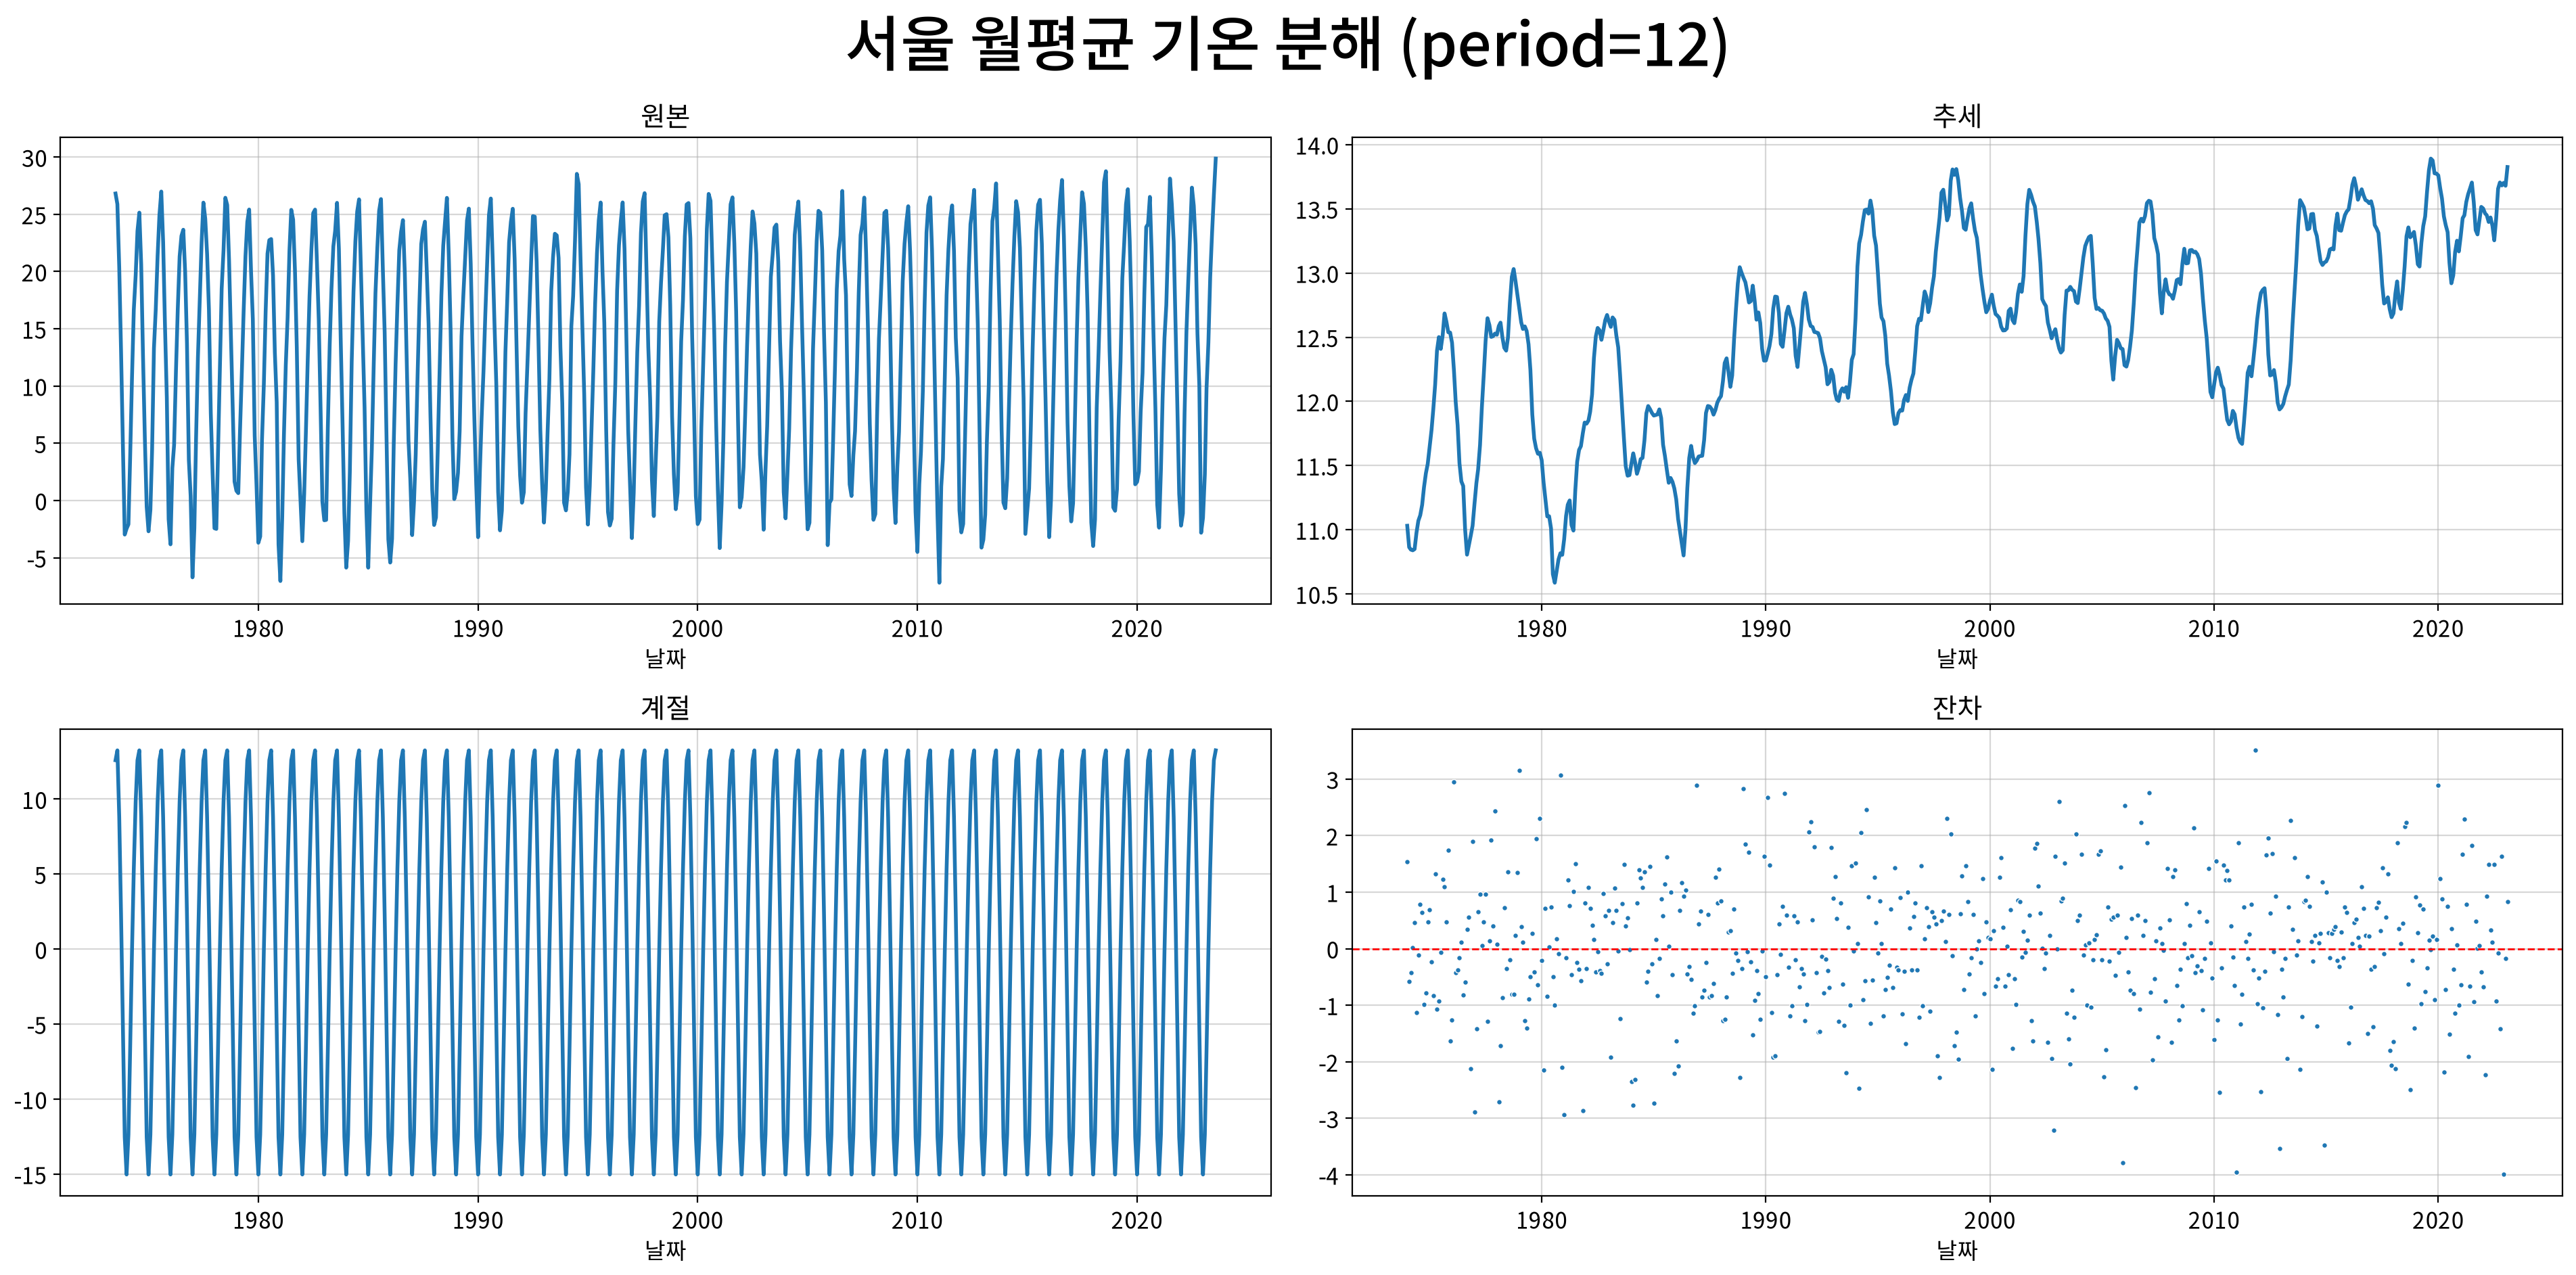

,원본,추세,계절,잔차
날짜,,,,
1974-01-01,-2.458,11.031,-15.024,1.535
1974-02-01,-2.079,10.864,-12.361,-0.582
1974-03-01,3.687,10.845,-6.728,-0.430


In [11]:
# model 을 주지 않으면 가법 · 승법을 스스로 판정한다
sd = my_ts.decompose(df, 12, "평균기온(℃)",
                     title="서울 월평균 기온 분해 (period=12)",
                     width=960, height=480)

sd.dropna().head(3)

#### 성분의 크기 비교 — 무엇이 원본을 흔드는가

In [12]:
# 세 성분 중 어느 것이 원본을 설명하는지 표준편차로 확인한다
sd.std().round(3).to_frame("표준편차")

,표준편차
원본,9.932
추세,0.739
계절,9.809
잔차,1.213


#### 계절지수 — 위치를 월로 옮겨서 읽기

결합 방식: additive
최고 위치: 2 (13.2459)
최저 위치: 7 (-15.0241)


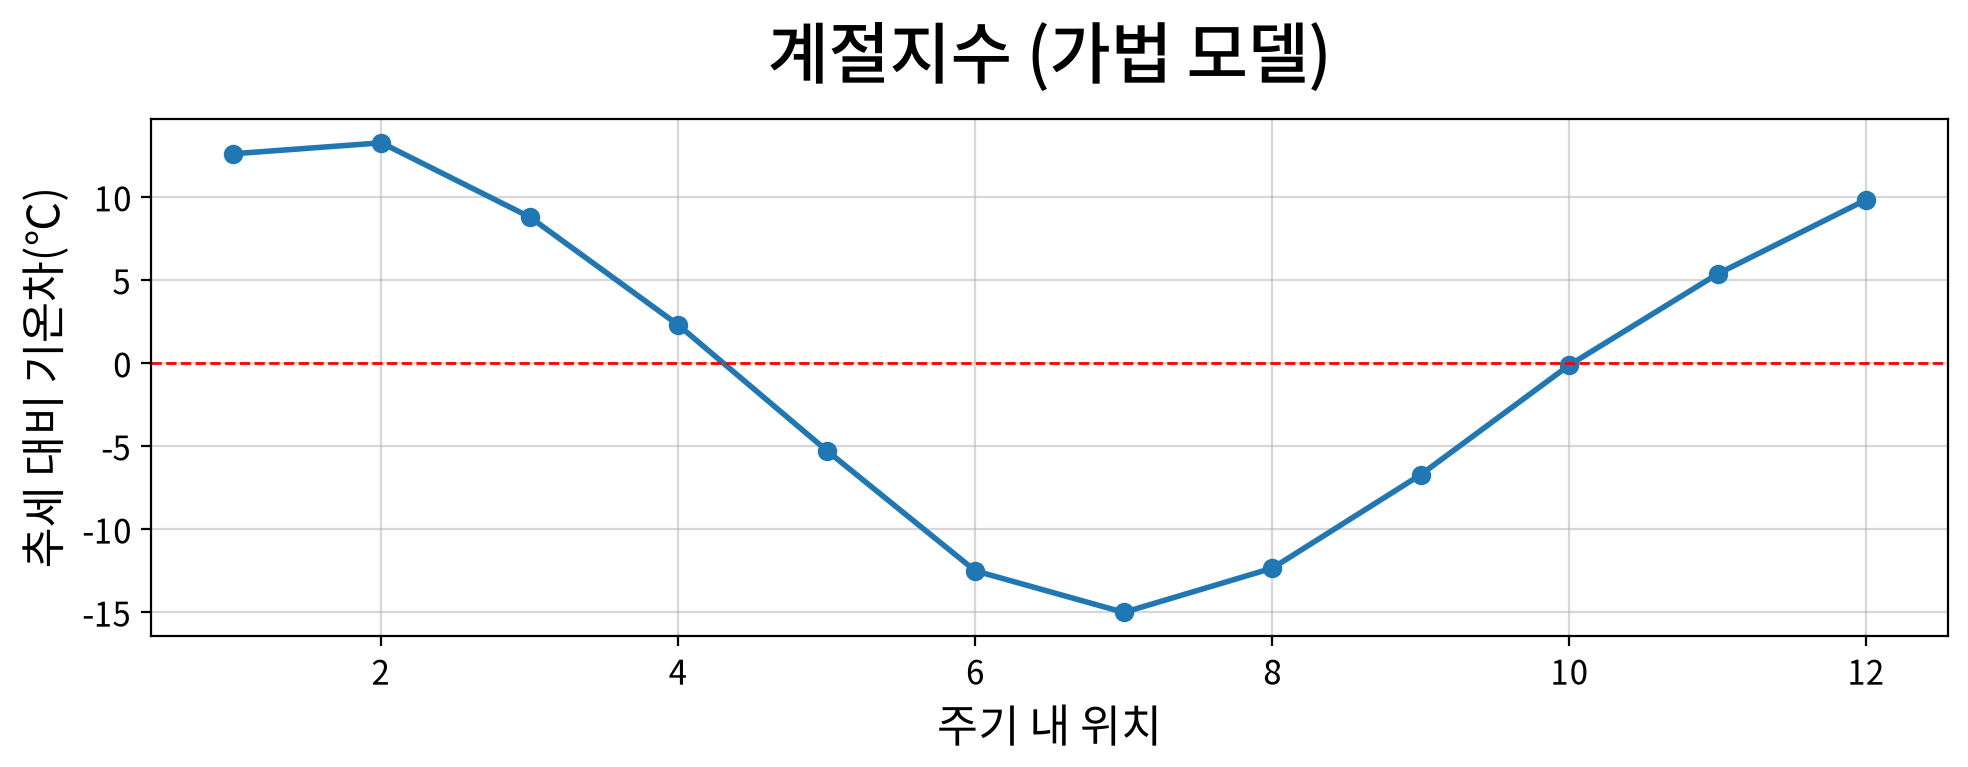


데이터 시작 월: 7월  →  위치 1 = 7월


월,1,2,3,4,5,6,7,8,9,10,11,12
계절지수,-15.024,-12.361,-6.728,-0.136,5.360,9.824,12.584,13.246,8.773,2.273,-5.288,-12.524


In [13]:
ss = my_ts.report_seasonal(df, 12, "평균기온(℃)",
                           title="계절지수 (가법 모델)",
                           xlabel="주기 내 위치", ylabel="추세 대비 기온차(℃)",
                           width=1000, height=400)

# ★ 위치는 월이 아니다. 데이터가 시작하는 달을 1로 놓고 주기 안에서 센다.
start = df.index[0].month
ss["월"] = [((start - 1 + p - 1) % 12) + 1 for p in ss.index]

print()
print(f"데이터 시작 월: {start}월  →  위치 1 = {start}월")

# 월 순서로 다시 세운다
month_table = ss.set_index("월")[["계절지수"]].sort_index().round(3)
month_table.T

#### 계절조정 — 원본에서 계절을 뺀다

결합 방식: additive (원본 − 계절)


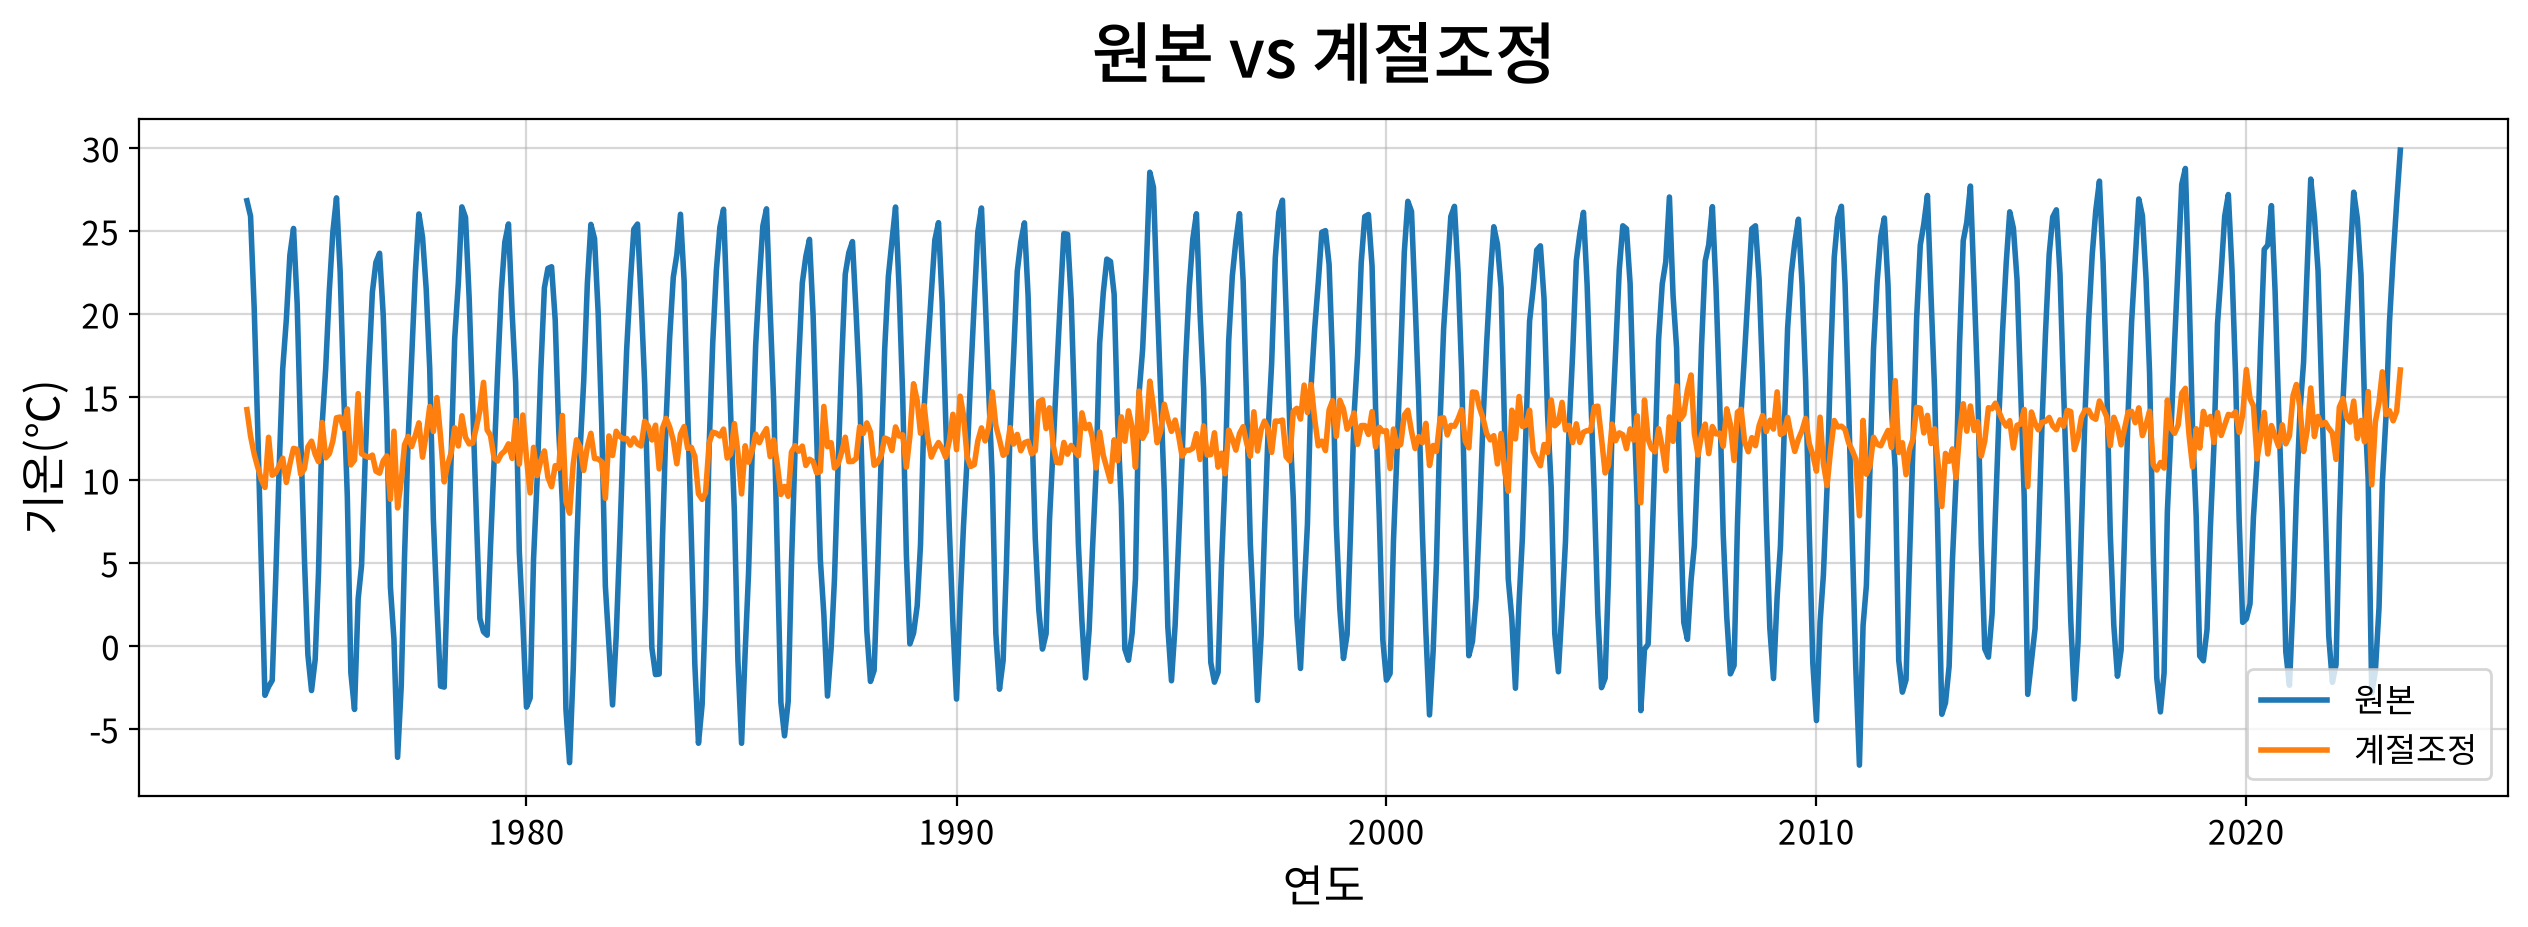


원본     : 표준편차 9.932  |  관측치 602개
계절조정 : 표준편차 1.450  |  관측치 602개


In [14]:
# 가법 모델이므로 원본에서 계절을 뺀다 (승법이었다면 나눔)
adjusted = my_ts.adjust_seasonal(df, 12, "평균기온(℃)",
                                 title="원본 vs 계절조정",
                                 xlabel="연도", ylabel="기온(℃)",
                                 width=1280, height=480)

print()
print(f"원본     : 표준편차 {df['평균기온(℃)'].std():.3f}  |  관측치 {len(df)}개")
print(f"계절조정 : 표준편차 {adjusted.std():.3f}  |  관측치 {len(adjusted)}개")

#### 계절차분 — 전년 동월과 뺀다

In [15]:
# 1단원에서 확정한 전처리(d=0, D=1, s=12)를 그대로 재현한다
diffed = my_ts.transform(df, "평균기온(℃)", log=False, diff=0, seasonal_diff=1, period=12)

print(f"계절차분 : 표준편차 {diffed.std():.3f}  |  관측치 {len(diffed)}개")
print(f"원본 대비 사라진 관측치 : {len(df) - len(diffed)}개")

계절차분 : 표준편차 1.881  |  관측치 590개
원본 대비 사라진 관측치 : 12개


#### 두 결과를 구간별로 비교 — 어느 쪽을 보고할 것인가

In [16]:
print("■ 계절조정 (원본 − 계절)")
display(my_ts.report_split(adjusted, size=3))

print("■ 계절차분 (전년 동월 대비)")
display(my_ts.report_split(diffed, size=3))

■ 계절조정 (원본 − 계절)


,시작,종료,관측치 수,평균,표준편차,변동계수
구간,,,,,,
구간 1,1973-07-01,1990-02-01,200,11.891,1.401,0.118
구간 2,1990-03-01,2006-10-01,200,12.747,1.278,0.100
구간 3,2006-11-01,2023-06-01,200,13.048,1.391,0.107


■ 계절차분 (전년 동월 대비)


,시작,종료,관측치 수,평균,표준편차,변동계수
구간,,,,,,
구간 1,1974-07-01,1990-10-01,196,0.088,1.978,22.555
구간 2,1990-11-01,2007-02-01,196,0.046,1.889,40.746
구간 3,2007-03-01,2023-06-01,196,0.021,1.765,82.802


### 문제 풀이

#### 1. 사무관에게 보여줄 분해 결과를 만들려면 세 성분이 어떤 방식으로 결합되어 있는지부터 정해야 합니다. 이 자료는 가법과 승법 중 어느 방식으로 판정되나요?

- **정답**: `가법`
- **복습 개념**: 결합 방식(가법 · 승법) 판정입니다. 가법은 `원본 = 추세 + 계절 + 잔차`, 승법은 `원본 = 추세 × 계절 × 잔차` 입니다. 이 판정이 뒤의 모든 계산을 바꿉니다 — 계절지수를 ℃로 읽을지 배수로 읽을지, 계절조정에서 뺄지 나눌지가 여기서 갈립니다.
- **풀이 접근**: 결합 방식을 지정하지 않고 분해하면 함수가 스스로 판정해 알려 줍니다. 판정 기준은 주기 단위로 묶었을 때 **표준편차가 일정한지, 변동계수가 일정한지** 입니다. 규모가 커질 때 변동폭도 비례해서 커지면 승법이고, 변동폭이 그대로면 가법입니다.
- **근거(계산 결과)**: 출력이 `결합 방식 자동 판정: additive` 로 **가법**입니다. 기온은 ℃라는 절대 눈금이라 평균이 11℃에서 13℃로 올라도 여름·겨울의 진폭은 그대로입니다. 2단원에서 이동표준편차가 평평해 로그변환이 필요 없다고 판정한 것과 같은 결론입니다.
- **헷갈리기 쉬운 점**: 실습의 항공 승객 데이터는 승법이었습니다. 승객 수는 규모가 4배가 되면 성수기·비수기 격차도 4배로 벌어지기 때문입니다. "기온은 가법, 매출·인원은 승법"으로 외우지 말고 **규모가 커질 때 진폭도 함께 커지는가**를 매번 확인하세요. 영어로 답할 때는 `additive` 입니다.

#### 2. "원본 그래프로는 온난화가 안 보인다"는 말을 숫자로 뒷받침해야 합니다. 원본의 흔들림을 거의 전부 만들어내는 성분의 표준편차는 얼마인가요? (소수 셋째 자리)

- **정답**: `9.809`
- **복습 개념**: 성분별 표준편차 비교입니다. 분해가 끝나면 어느 성분이 원본의 변동을 만들고 있는지 표준편차 하나로 판정할 수 있습니다. 원본의 표준편차와 거의 같은 값을 가진 성분이 곧 지배 성분입니다.
- **풀이 접근**: 분해 결과 네 성분(원본 · 추세 · 계절 · 잔차)의 표준편차를 한 표로 놓고 원본과 비교합니다. 어느 성분이 원본과 가장 가까운 값인지를 봅니다.
- **근거(계산 결과)**: 원본 9.932 · 추세 0.739 · **계절 9.809** · 잔차 1.213 입니다. 계절 성분 하나가 원본의 흔들림을 거의 전부 설명하고, 추세는 0.739에 불과합니다. 1단원에서 "월별 평균의 표준편차 10.242가 전체 표준편차 9.932와 맞먹는다"고 판정한 것과 같은 결론입니다.
- **실무 포인트**: 이 한 줄이 사무관의 질문에 대한 답입니다. 계절이 9.809℃를 흔드는데 추세는 0.739℃만 움직이니, 원본 그래프에서 온난화가 보일 수가 없습니다. 2단원에서 평활을 하고 나서야 +2.830℃가 드러난 이유도 같습니다. 보고서에는 "계절이 추세보다 13배 크다"는 문장을 이 표와 함께 실으면 됩니다.

#### 3. 겨울이 얼마나 추운 쪽으로 끌어내리는지 보여주려 합니다. 1월의 계절지수는 몇 ℃인가요? (소수 셋째 자리)

- **정답**: `-15.024`
- **복습 개념**: 계절지수 읽기이고, 동시에 **"주기 내 위치"는 월이 아니다**를 확인하는 문항입니다. 위치는 데이터가 시작하는 달을 1로 놓고 주기 안에서 세므로, 시작 월이 1월이 아니면 위치와 월이 어긋납니다.
- **풀이 접근**: 계절지수표를 얻으면 인덱스가 1 ~ 12의 **위치**로 되어 있습니다. 이 데이터는 1973년 **7월**부터 시작하므로 위치 1이 7월이고, 1월은 위치 7입니다. 위치를 월로 옮긴 뒤 1월 행을 읽습니다. 가법 모델이므로 이 값은 배수가 아니라 **℃ 단위의 더하고 빼는 값**입니다.
- **근거(계산 결과)**: 함수는 `최저 위치: 7 (-15.0241)` 이라고 출력합니다. 위치 7 = 1월이므로 1월의 계절지수는 **−15.024℃** 입니다. 즉 1월은 그 시점의 연 추세 수준보다 15.024℃ 낮은 것이 정상입니다. 반대쪽 최고는 위치 2인 8월의 +13.246℃입니다.
- **자주 하는 실수**: 출력의 `최저 위치: 7` 을 그대로 옮겨 "7월"이라고 답하기 쉽습니다. 그런데 7월은 이 데이터에서 두 번째로 더운 달(+12.584℃)입니다. 8월이 가장 덥고 1월이 가장 춥다는 상식과 출력이 어긋나면 **모듈 함수의 출력을 옮겨 적기 전에 위치를 월로 환산**하세요. 1단원에서 `adf_diff()` 의 권고를 그대로 받아들이지 않았던 것과 같은 태도입니다.

#### 4. 계절을 걷어낸 그래프를 보고서에 실으려 합니다. 계절 요인을 제거한 계열의 표준편차는 얼마인가요? (소수 셋째 자리)

- **정답**: `1.450`
- **복습 개념**: 계절조정입니다. 가법 모델이므로 **원본에서 계절 성분을 뺍니다**(승법이었다면 나눕니다). 계절이 사라진 만큼 흔들림이 줄어들고, 줄어든 정도가 곧 계절이 차지하던 몫입니다.
- **풀이 접근**: 분해에서 얻은 계절 성분을 원본에서 빼고, 그 결과의 표준편차를 원본의 표준편차와 나란히 놓습니다. 관측치 수도 함께 확인해 두면 다음 문항과 비교할 수 있습니다.
- **근거(계산 결과)**: 원본 9.932 → 계절조정 **1.450** 으로 약 **7분의 1** 이 됩니다. 흔들림의 대부분이 계절이었다는 뜻입니다. 다만 0이 되지 않고 1.450이 남는데, 이 남은 울퉁불퉁함이 **잔차**(표준편차 1.213)와 **추세**(0.739)입니다.
- **함께 생각해 볼 점**: 2단원에서 창 크기 12의 이동평균을 했을 때는 표준편차가 0.745까지 떨어졌습니다. 계절조정은 1.450이니 이동평균이 더 매끈합니다. 이동평균은 계절뿐 아니라 불규칙한 흔들림까지 함께 뭉개기 때문입니다. 계절조정은 잔차를 남겨 두므로 **이상 시점을 찾을 수 있고**, 이동평균은 그것까지 지워 버립니다. 목적이 다르면 도구도 달라집니다.

#### 5. 계절을 지우는 다른 방법인 계절차분도 함께 시도했습니다. 계절차분을 적용한 뒤 남는 관측치는 몇 개인가요? (숫자만)

- **정답**: `590`
- **복습 개념**: 계절차분입니다. 각 값에서 **전년 동월 값을 빼는** 방식이므로, 뺄 대상이 없는 첫 1년치는 결과가 나오지 않습니다. 계절조정과 결정적으로 다른 지점이 바로 이 **데이터 손실**입니다.
- **풀이 접근**: 1단원에서 확정한 전처리($d = 0$, $D = 1$, $s = 12$)를 그대로 적용하고, 결과의 길이를 원본 602개와 비교합니다.
- **근거(계산 결과)**: **590개** 입니다. 602 − 590 = 12개, 즉 **앞 12개월(1973-07 ~ 1974-06)이 사라집니다.** 반면 앞 문항의 계절조정은 602개가 그대로 남았습니다. 표준편차는 계절차분 1.881, 계절조정 1.450으로 **둘 다 계절성은 똑같이 지워졌습니다.**
- **헷갈리기 쉬운 점**: 분해 결과에서 추세·잔차가 계산된 구간도 590개인데, 이유가 다릅니다. 계절차분은 앞 12개월이 통째로 없어진 것이고, 분해의 추세는 중심이동평균이라 **앞 6개월과 뒤 6개월**이 비어 590개가 된 것입니다. 숫자가 같다고 같은 현상이 아닙니다.

#### 6. 사무관의 마지막 물음에 답할 차례입니다. 계절조정과 계절차분 중 시민 보고서에 실어야 하는 계열은 어느 것인가요? (용어)

- **정답**: `계절조정`
- **복습 개념**: **목적이 방법을 정한다**는 원칙입니다. 두 방법 모두 계절을 지우지만, 계절조정은 추세를 남기고 계절차분은 추세까지 지웁니다. 사람에게 보고할 때는 "몇 도인가"라는 수준 정보가 필요하고, 모형에 넣을 때는 정상성이 필요합니다.
- **풀이 접근**: 두 계열을 각각 세 구간으로 잘라 **구간 평균**을 비교합니다. 표준편차만 보면 둘이 비슷해 보이므로 판단이 서지 않습니다. 평균이 어떻게 움직이는지를 보아야 차이가 드러납니다.
- **근거(계산 결과)**: 계절조정은 구간 평균이 **11.891 → 12.747 → 13.048** 로 올라가 **추세가 그대로 남아 있습니다.** 계절차분은 **0.088 → 0.046 → 0.021** 로 전부 0 근처여서 **수준 정보가 사라졌습니다.** 시민에게 "서울이 더워지고 있다"를 보여줄 수 있는 쪽은 **계절조정** 입니다. 경제 통계의 "계절조정 실업률"이 바로 이것입니다.
- **결론**: 사무관에게 낼 답은 이렇습니다 — 계절조정 계열의 그래프와 구간 평균 표(11.891 → 13.048)를 싣고, 상승 폭은 2단원에서 구한 +2.830℃를 함께 적습니다. 계절차분 계열은 보고서에 쓸 수 없지만 버리지도 않습니다. 뒤이어 예측 모형을 만들 때 필요한 정상 시계열이 그쪽이기 때문입니다. 계절조정 계열은 구간 평균이 계속 올라가므로 정상 시계열이 아니고, 그대로 모형에 넣을 수 없습니다. 참고로 계절차분 표의 변동계수(22 ~ 82)는 볼 필요가 없습니다 — 평균이 0에 가까운 계열에서는 변동계수를 읽지 않습니다.